In [2]:
import sys
sys.path.append("../../")

In [74]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from src.data.loader import *
from src.data.preprocessor import *

In [4]:
url1 ='/home/anchitkaushal7/projects/Retail_Demand_Forecasting_and_Fraud_Detection_System/data/raw/calendar.csv'
url2 ='/home/anchitkaushal7/projects/Retail_Demand_Forecasting_and_Fraud_Detection_System/data/raw/sales_train_validation.csv'
url3 ='/home/anchitkaushal7/projects/Retail_Demand_Forecasting_and_Fraud_Detection_System/data/raw/sell_prices.csv'

In [5]:
calendar1 = load_calendar(url1)
sales1 = load_sales(url2)
sellprices1 = load_prices(url3)

__EDA of Calendar dataset__

In [6]:
calendar = calendar1.copy()

In [7]:
calendar.shape

(1969, 14)

In [8]:
calendar.head(20)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [38]:
calendar.columns

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'is_event'],
      dtype='str')

In [9]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB


In [10]:
calendar.dtypes

date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d                 str
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

In [11]:
calendar.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,1969,1969,2011-01-29,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wm_yr_wk,1969.0,NaN,NaN,NaN,11347.086338,155.277043,11101.0,11219.0,11337.0,11502.0,11621.0
weekday,1969,7,Saturday,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wday,1969.0,NaN,NaN,NaN,3.997461,2.001141,1.0,2.0,4.0,6.0,7.0
month,1969.0,NaN,NaN,NaN,6.325546,3.416864,1.0,3.0,6.0,9.0,12.0
year,1969.0,NaN,NaN,NaN,2013.288471,1.580198,2011.0,2012.0,2013.0,2015.0,2016.0
d,1969,1969,d_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name_1,162,30,SuperBowl,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type_1,162,4,Religious,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name_2,5,4,Father's day,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
calendar.duplicated().sum()

np.int64(0)

In [13]:
calendar = clean_calendar(calendar)

Saving cleaned version of calendar dataset 

In [14]:
calendar.to_csv('/home/anchitkaushal7/projects/Retail_Demand_Forecasting_and_Fraud_Detection_System/data/interim/clean_calendar.csv')

__EDA of Sales data__

In [15]:
sales = sales1.copy()

In [16]:
pd.set_option("display.max_columns",None)
sales.tail(10)

id      item_id  dept_id cat_id store_id  \
30480  FOODS_3_818_WI_3_validation  FOODS_3_818  FOODS_3  FOODS     WI_3   
30481  FOODS_3_819_WI_3_validation  FOODS_3_819  FOODS_3  FOODS     WI_3   
30482  FOODS_3_820_WI_3_validation  FOODS_3_820  FOODS_3  FOODS     WI_3   
30483  FOODS_3_821_WI_3_validation  FOODS_3_821  FOODS_3  FOODS     WI_3   
30484  FOODS_3_822_WI_3_validation  FOODS_3_822  FOODS_3  FOODS     WI_3   
30485  FOODS_3_823_WI_3_validation  FOODS_3_823  FOODS_3  FOODS     WI_3   
30486  FOODS_3_824_WI_3_validation  FOODS_3_824  FOODS_3  FOODS     WI_3   
30487  FOODS_3_825_WI_3_validation  FOODS_3_825  FOODS_3  FOODS     WI_3   
30488  FOODS_3_826_WI_3_validation  FOODS_3_826  FOODS_3  FOODS     WI_3   
30489  FOODS_3_827_WI_3_validation  FOODS_3_827  FOODS_3  FOODS     WI_3   

      state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
30480       WI    0    0    0    0    0    0    0    0    0     0     0     0   
30481       WI   14   11    5    6    5   13   18   13   18    19     1    12   
30482       WI    1    1    1    1    1    2    1    3    4     1     1     6   
30483       WI    0    0    0    0    0    0    0    0    0     0     0     0   
30484       WI    4    4    2    5    2    7    8    4    4     1    10     7   
30485       WI    0    0    2    2    0    3    1    4    1     0     0     3   
30486       WI    0    0    0    0    0    5    0    1    1     3     1     1   
30487       WI    0    6    0    2    2    4    1    8    5     2     7     5   
30488       WI    0    0    0    0    0    0    0    0    0     0     0     0   
30489       WI    0    0    0    0    0    0    0    0    0     0     0     0   

       d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
30480     0     0     0     0     0     0     0     0     0     0     0     0   
30481    13     7    15     9    14    12     5    17    12    12     8     8   
30482     2     3     3     6     0     2     3     4     1     2     1     0   
30483     0     0     0     0     0     0     0     0     0     0     0     0   
30484     3     0    16    10     9     0     0     0     0     0     0     0   
30485     4     4     0     0     1     0     1     1     7     7     3     6   
30486     0     4     2     0     1     2     1     1     0     0     0     0   
30487     3     5    20     8    10     3     3     4     7     2     3     5   
30488     0     0     0     0     0     0     0     0     0     0     0     0   
30489     0     0     0     0     0     0     0     0     0     0     0     0   

       d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
30480     0     0     0     0     0     0     0     0     0     0     0     0   
30481     4     3     4     9     6    10     6     7     9     7     7    13   
30482     1     2     2     0     3     0     0     2     1     3     2     0   
30483     0     0     0     0     0     0     0     0     0     0     0     0   
30484     0     0     0     0     0     0     0     0     0     0     0     0   
30485     3     3     7    12     4     2     7     5    12     5     3     3   
30486     3     1     1     1     2     0     1     0     1     1     1     3   
30487     6     3     4     1     2     5     1     2     2     2     1     9   
30488     0     0     0     0     0     0     0     0     0     0     0     0   
30489     0     0     0     0     0     0     0     0     0     0     0     0   

       d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
30480     0     0     0     0     0     0     0     0     0     0     0     0   
30481     4     0    16     2    11     4     5     8    11    11     7     7   
30482     2     2     1     1     2     2     0     0     0     0     0     0   
30483     0     0     0     0     0     0     0     0     0     0     0     0   
30484     0     0     0     0     0     0     0     0     0     0     0     0   
30485     7     6     4     6    

In [17]:
sales.shape

(30490, 1919)

In [18]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 448.2 MB


In [19]:
print("========== SALES DATA OVERVIEW ==========")

print("Shape:", sales.shape)

print("\nFirst 10 columns:")
print(sales.columns[:10].tolist())

print("\nLast 10 columns:")
print(sales.columns[-10:].tolist())

print("\nData types:")
print(sales.dtypes.value_counts())

print("\nMissing values:")
print(sales.isna().sum().sum())

print("\nDuplicate rows:")
print(sales.duplicated().sum())

day_columns = [c for c in sales.columns if c.startswith("d_")]

print("\nNumber of daily columns:", len(day_columns))
print("First day:", day_columns[0])
print("Last day:", day_columns[-1])

print("\nSample:")
display(sales.iloc[:5, :10])

========== SALES DATA OVERVIEW ==========
Shape: (30490, 1919)

First 10 columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']

Last 10 columns:
['d_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

Data types:
int64    1913
str         6
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0

Number of daily columns: 1913
First day: d_1
Last day: d_1913

Sample:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0


In [20]:
sales.describe(include="str")

,id,item_id,dept_id,cat_id,store_id,state_id
count,30490,30490,30490,30490,30490,30490
unique,30490,3049,7,3,10,3
top,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,FOODS_3,FOODS,CA_1,CA
freq,1,10,8230,14370,3049,12196


In [21]:
sales = clean_sales(sales)

Sales dataset is already cleaned so we have no need to save it in interim folder.

__EDA of sellprices dataset__

In [22]:
sellprices = sellprices1.copy()

In [23]:
sellprices.shape

(6841121, 4)

In [24]:
sellprices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [25]:
sellprices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB


In [26]:
sellprices.duplicated().sum()

np.int64(0)

In [27]:
sellprices.isna().sum().sum()

np.int64(0)

In [28]:
sellprices.describe(include="all")

,store_id,item_id,wm_yr_wk,sell_price
count,6841121,6841121,6.841121e+06,6.841121e+06
unique,10,3049,NaN,NaN
top,TX_2,HOBBIES_1_010,NaN,NaN
freq,701214,2820,NaN,NaN
mean,NaN,NaN,1.138294e+04,4.410952e+00
std,NaN,NaN,1.486100e+02,3.408814e+00
min,NaN,NaN,1.110100e+04,1.000000e-02
25%,NaN,NaN,1.124700e+04,2.180000e+00
50%,NaN,NaN,1.141100e+04,3.470000e+00
75%,NaN,NaN,1.151700e+04,5.840000e+00


In [29]:
sellprices= clean_prices(sellprices)

sellprices dataset is also cleaned so we have no need to save it in interim folder.

__MAKING TIME SERIES FROM DATSETS__

In [33]:
day_cols = [
    col for col in sales.columns
    if col.startswith("d_")
    ]
print("Number of daily sales columns:", len(day_columns))



Number of daily sales columns: 1913


In [32]:
id_cols = [
    'id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'
]

In [ ]:
daily_sales = sales[day_cols].sum(axis=0)

In [35]:
daily_sales.head(10)

d_1     32631
d_2     31749
d_3     23783
d_4     25412
d_5     19146
d_6     29211
d_7     28010
d_8     37932
d_9     32736
d_10    25572
dtype: int64

In [36]:
daily_sales_df = pd.DataFrame({
    "d": daily_sales.index,
    "sales": daily_sales.values
})

daily_sales_df.head()

,d,sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [40]:
calendar_ana = calendar[
    [
        "d",
        "date",
        "weekday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
        "is_event"
    ]
]

In [41]:
daily_sales_df = daily_sales_df.merge(
    calendar_ana,on = 'd',how='left'
    )

In [43]:
daily_sales_df['date'] = pd.to_datetime(
  daily_sales_df['date']
)

In [44]:
daily_sales_df = daily_sales_df.sort_values(
    "date"
).reset_index(drop=True)

Here we have total sales of each day

In [46]:
daily_sales_df[
    ["d", "date", "sales"]
].head(11)

,d,date,sales
0,d_1,2011-01-29,32631
1,d_2,2011-01-30,31749
2,d_3,2011-01-31,23783
3,d_4,2011-02-01,25412
4,d_5,2011-02-02,19146
5,d_6,2011-02-03,29211
6,d_7,2011-02-04,28010
7,d_8,2011-02-05,37932
8,d_9,2011-02-06,32736
9,d_10,2011-02-07,25572


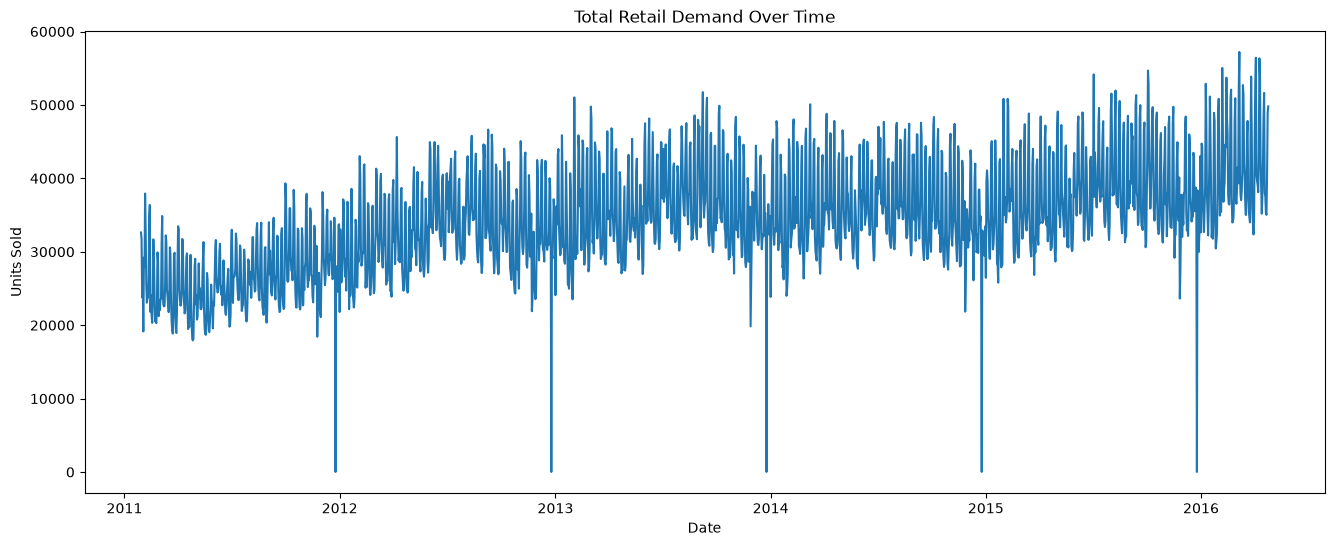

In [52]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["sales"]
)

plt.title("Total Retail Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

The demand flauctuates significantly from day to day.
There is upward trend.
May be there are some repeating pattrens.
There many large demand spikes.

__Calculating Rolling mean to see trend more efficiently__

In [53]:
daily_sales_df["rolling_7"] = (
    daily_sales_df["sales"]
    .rolling(7)
    .mean()
)

daily_sales_df["rolling_28"] = (
    daily_sales_df["sales"]
    .rolling(28)
    .mean()
)

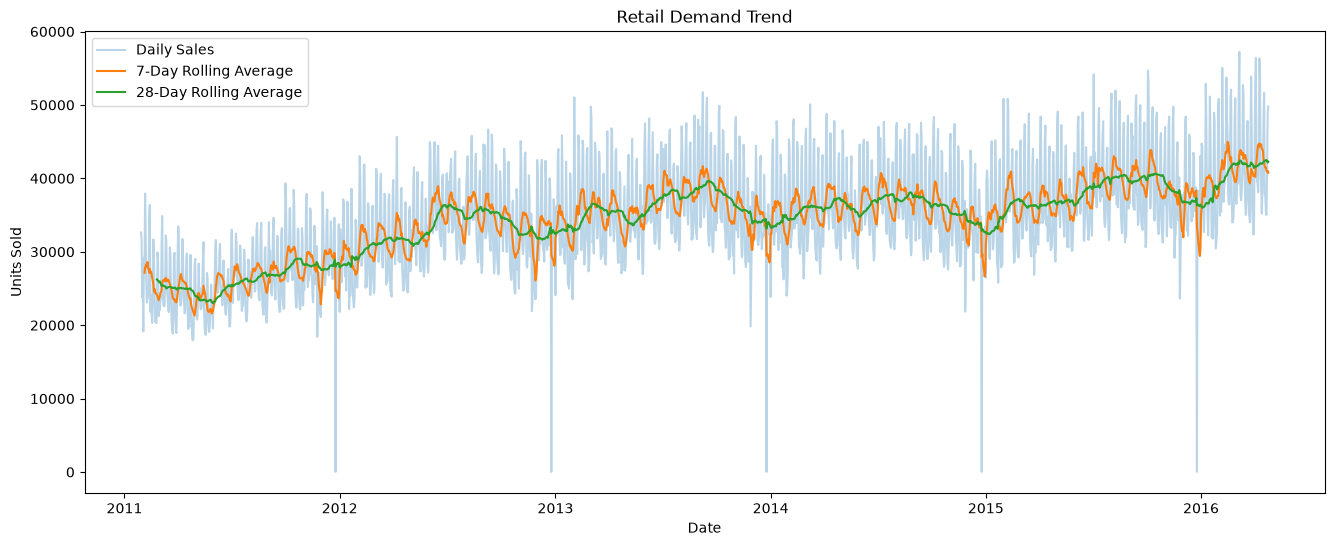

In [56]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["sales"],
    alpha=0.3,
    label="Daily Sales"
)

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["rolling_7"],
    label="7-Day Rolling Average"
)

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["rolling_28"],
    label="28-Day Rolling Average"
)

plt.title("Retail Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.show()

Both 7 and 28 days moving average state that trend is going upward.

__SEASONALITY ANALYSIS__

----checking weekly seasonality----

In [59]:
daily_sales_df[
    ["date", "weekday", "sales"]
].head(7)

,date,weekday,sales
0,2011-01-29,Saturday,32631
1,2011-01-30,Sunday,31749
2,2011-01-31,Monday,23783
3,2011-02-01,Tuesday,25412
4,2011-02-02,Wednesday,19146
5,2011-02-03,Thursday,29211
6,2011-02-04,Friday,28010


In [60]:
weekly_pattern = (
    daily_sales_df
    .groupby("weekday")["sales"]
    .mean()
)

print(weekly_pattern)

weekday
Friday       34225.985348
Monday       32852.967033
Saturday     41546.894161
Sunday       41130.021898
Thursday     30205.007326
Tuesday      30368.780220
Wednesday    30010.021978
Name: sales, dtype: float64


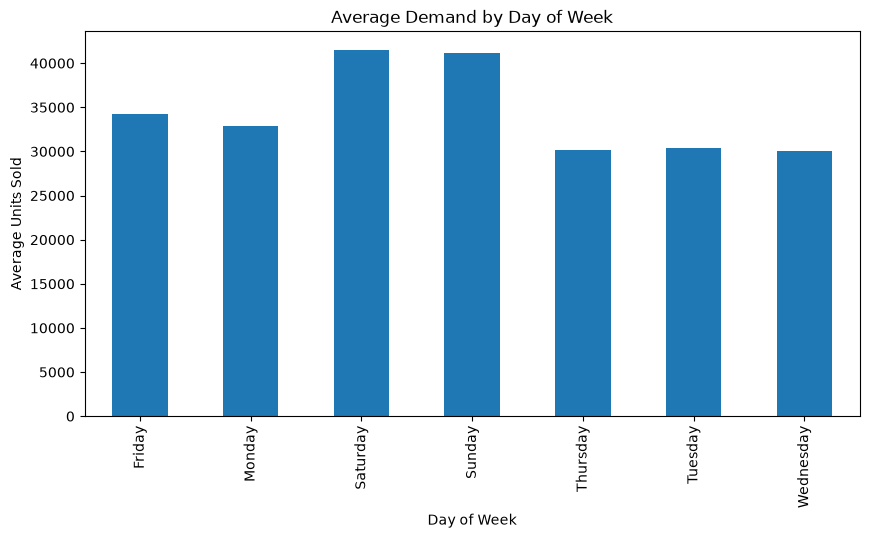

In [61]:
weekly_pattern.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")

plt.show()

Their is a weekly seasonality

----checking monthly seasonality----

In [63]:
monthly_pattern = (
    daily_sales_df
    .groupby("month")["sales"]
    .mean()
)

print(monthly_pattern)

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: sales, dtype: float64


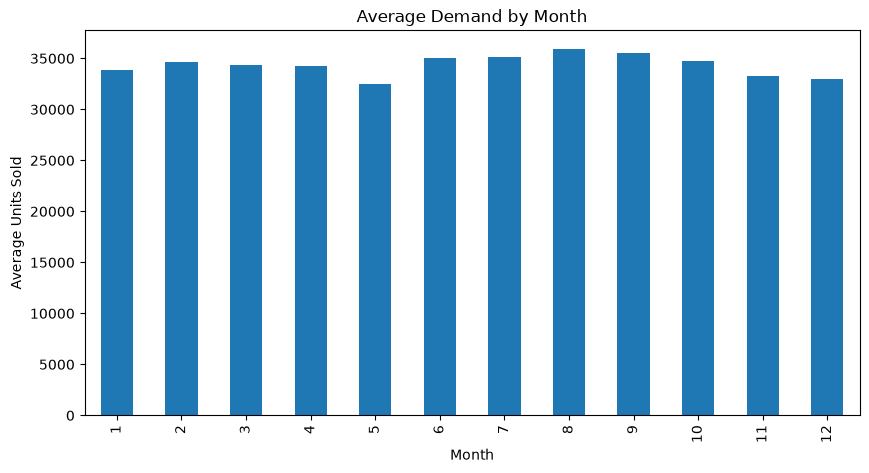

In [68]:
monthly_pattern.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.show()

The monthly analysis suggests some variation in demand across months, but the evidence for strong monthly seasonality is relatively weak.

__CHECKING IS DEMAND CHANGES FROM YEAR TO YEAR__

In [69]:
yearly_pattern = (
    daily_sales_df
    .groupby("year")["sales"]
    .mean()
)

print(yearly_pattern)

year
2011    26280.667656
2012    32955.838798
2013    35988.364384
2014    35862.400000
2015    37810.441096
2016    41309.973913
Name: sales, dtype: float64


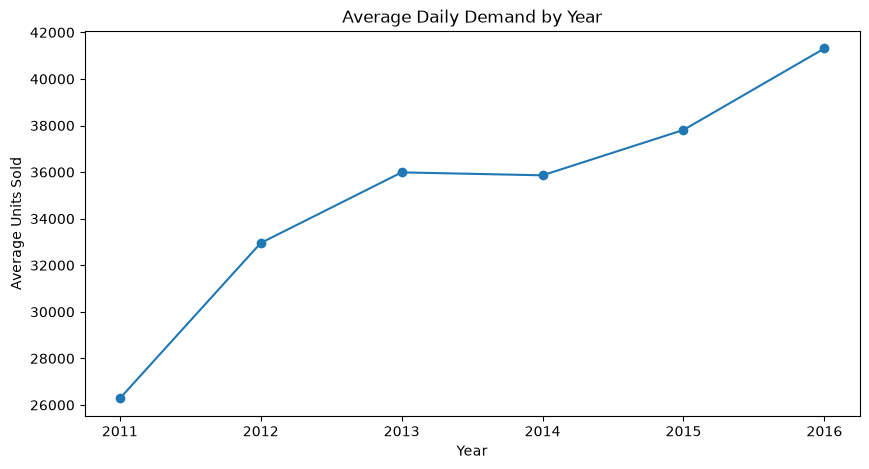

In [70]:
yearly_pattern.plot(
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Daily Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Units Sold")

plt.show()

This graph states that their is long term upward sesonality trend , but properly can't there is long term seasonality. 

__Performing Autocorrelation__

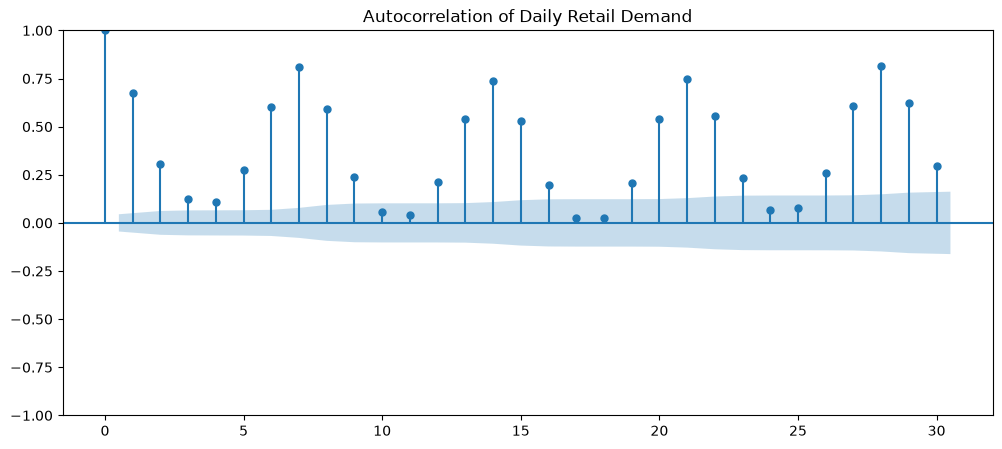

In [72]:
plt.figure(figsize=(12, 5))

plot_acf(
    daily_sales_df["sales"],
    lags=30,
    ax=plt.gca()
)

plt.title("Autocorrelation of Daily Retail Demand")

plt.show()

This auotcorrelation graph states that todays demand is correlated with todays demand. their is strong weekly seasonality

__Performing Decomposetion__

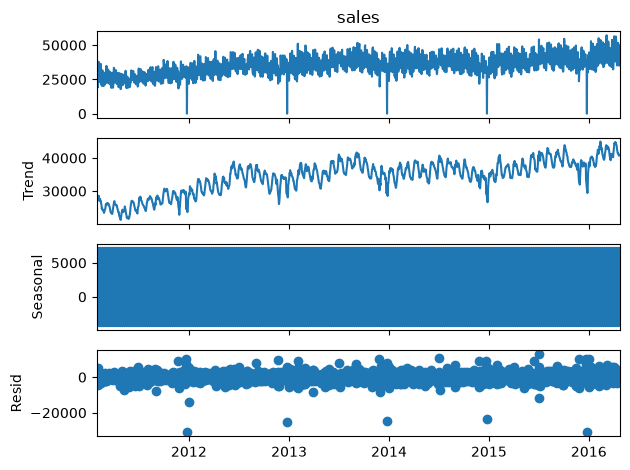

In [76]:
ts = (
    daily_sales_df
    .set_index("date")["sales"]
)

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

decomposition.plot().figsize=(14, 10)


plt.show()

Sales fluctuate heavily, grow over time, and contain noticeable sharp drops down to near-zero once a year.
The overall long-term trend of sales after filtering out daily noise and seasonal patterns.
Solid band showing strong weekly seasonality fluctuating between -4,000 and +7,000 around the average depending on the day of the week.
The extreme negative dots near -30,000 correspond directly to the store closure/holiday days.

__Effect of Events on sales__

In [78]:
event_sales = (
    daily_sales_df
    .groupby("is_event")["sales"]
    .mean()
)

print(event_sales)

is_event
0    34489.207504
1    32655.149351
Name: sales, dtype: float64


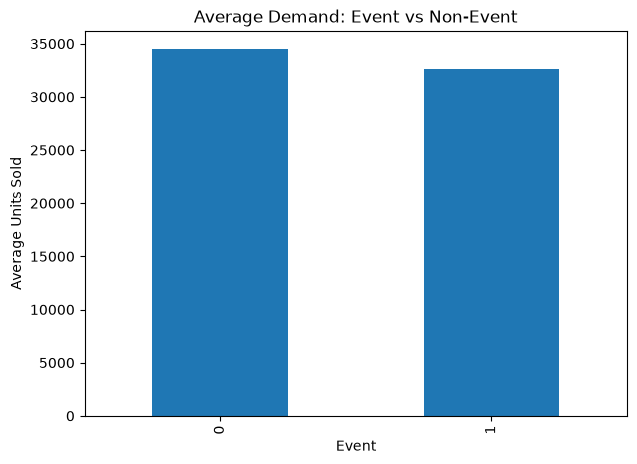

In [79]:
event_sales.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Demand: Event vs Non-Event")
plt.xlabel("Event")
plt.ylabel("Average Units Sold")

plt.show()

Events increased small amount of sales 

__SALES PER STORE__

In [80]:
store_sales = (
    sales
    .groupby("store_id")[day_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(store_sales)

store_id
CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
dtype: int64


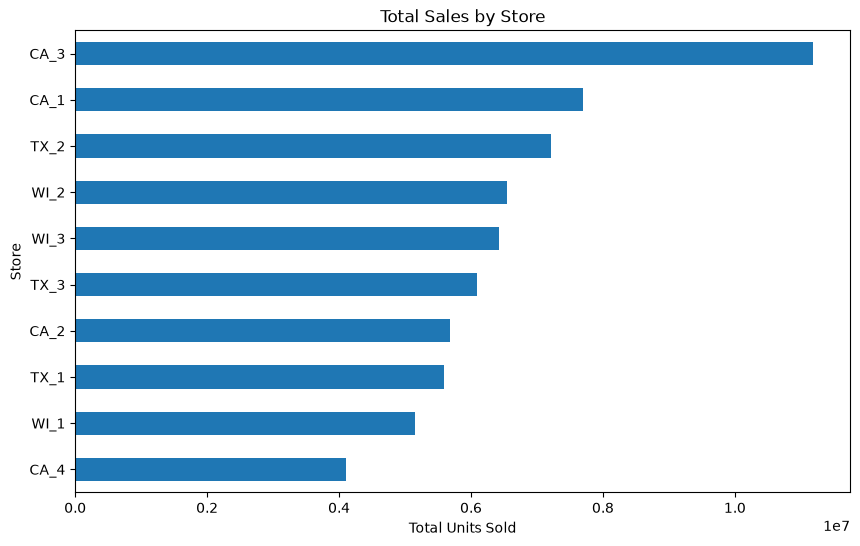

In [81]:
store_sales.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Sales by Store")
plt.xlabel("Total Units Sold")
plt.ylabel("Store")

plt.show()

Some sttores sold large amount of items while some stores sold less items than others , stores are not similar.

__Items categories that are sold most__

In [84]:
category_sales = (
    sales
    .groupby("cat_id")[day_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(category_sales)

cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
dtype: int64


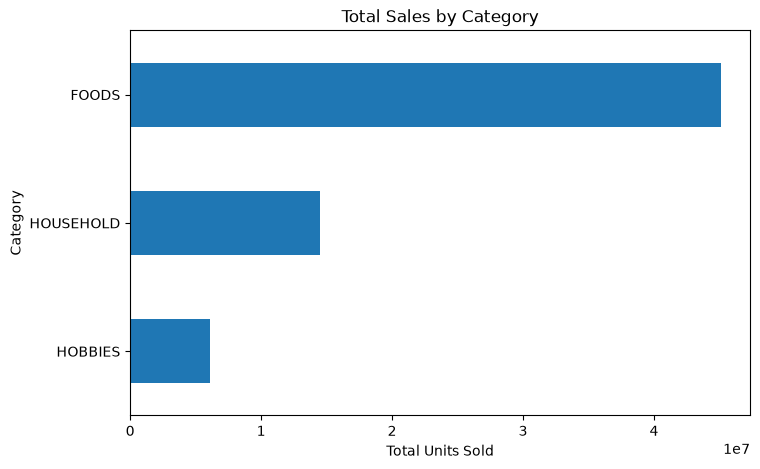

In [85]:
category_sales.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Total Sales by Category")
plt.xlabel("Total Units Sold")
plt.ylabel("Category")

plt.show()

Food items is the categories which is consistently more important than other item categories.

__Products which are sold most__

In [86]:
item_sales = (
    sales
    .groupby("item_id")[day_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(item_sales.head(20))

item_id
FOODS_3_090    1002529
FOODS_3_586     920242
FOODS_3_252     565299
FOODS_3_555     491287
FOODS_3_714     396172
FOODS_3_587     396119
FOODS_3_694     390001
FOODS_3_226     363082
FOODS_3_202     295689
FOODS_3_723     284333
FOODS_3_120     283104
FOODS_3_635     282134
FOODS_3_808     281879
FOODS_3_377     273289
FOODS_3_541     272624
FOODS_3_080     262650
FOODS_3_318     260598
FOODS_2_360     257119
FOODS_3_234     251160
FOODS_3_681     250018
dtype: int64


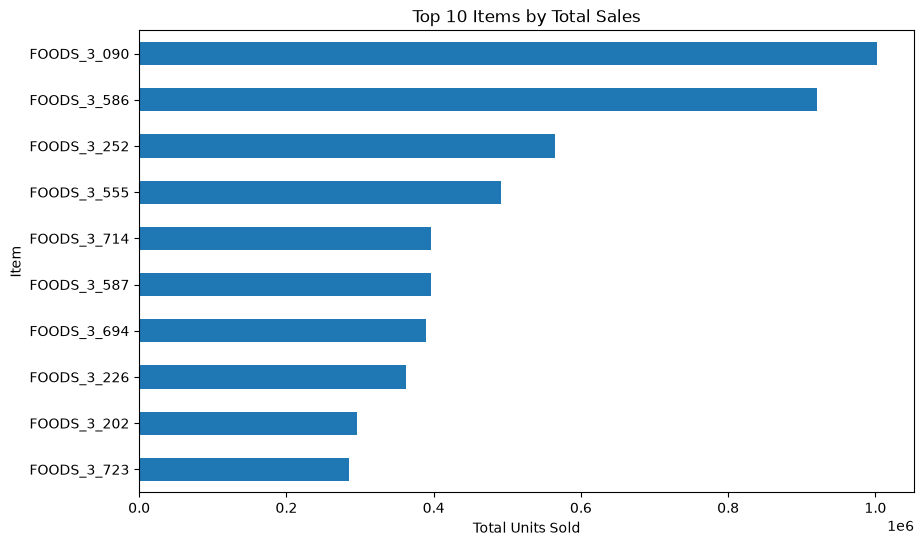

In [87]:
item_sales.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Items by Total Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Item")

plt.show()

Their is good variation of products sales but their are some products which are sold most.

In [88]:
daily_sales_df.nlargest(
    10,
    "sales"
)[
    ["date", "sales"]
]

,date,sales
1863,2016-03-06,57218
1891,2016-04-03,56425
1897,2016-04-09,56340
1834,2016-02-06,55040
1708,2015-10-03,54687
1616,2015-07-03,54154
1883,2016-03-26,53863
1898,2016-04-10,53856
1841,2016-02-13,53715
1709,2015-10-04,52895


In [91]:
top_days = daily_sales_df.nlargest(
    10,
    "sales"
)

top_days[
    [
        "date",
        "sales",
        "weekday",
        "month",
        "year",
        "is_event"
    ]
]

,date,sales,weekday,month,year,is_event
1863,2016-03-06,57218,Sunday,3,2016,0
1891,2016-04-03,56425,Sunday,4,2016,0
1897,2016-04-09,56340,Saturday,4,2016,0
1834,2016-02-06,55040,Saturday,2,2016,0
1708,2015-10-03,54687,Saturday,10,2015,0
1616,2015-07-03,54154,Friday,7,2015,0
1883,2016-03-26,53863,Saturday,3,2016,0
1898,2016-04-10,53856,Sunday,4,2016,0
1841,2016-02-13,53715,Saturday,2,2016,0
1709,2015-10-04,52895,Sunday,10,2015,0


We have top 10 days in which sales are high .
Most days are weekend that concluds most sales take place on weekends without any events.

In [92]:
daily_sales_df.to_csv('/home/anchitkaushal7/projects/Retail_Demand_Forecasting_and_Fraud_Detection_System/data/interim/daily_total_sales.csv')
print("file saved!!")

file saved!!
